# День розсилки: вівторок чи п'ятниця? Квазіексперимент на тригерних воркфлоу

**Контекст.** Користувачам, у яких падає активність, надсилають повідомлення (email і push) у двох воркфлоу:
`lessActivityThisWeek` та `lessActivityThisMonth`. Кожен воркфлоу має дві версії — з відправкою у **вівторок** або в **п'ятницю**.
Бізнес хоче залишити один день. Успіх = клік за посиланням (перехід на проєкт).

**Дані.** 41 925 рядків логу за 1 січня — 30 березня 2021: `user_id, sent_date, action_date, workflow, notice_type, action_type`.

**Коротка відповідь (TL;DR).**

| | П'ятниця | Вівторок |
|---|---|---|
| Відправок (спостережень) | 17 710 | 17 817 |
| Кліків (відправок з ≥1 кліком) | 1 290 | 995 |
| **CTR** | **7.28 %** | **5.58 %** |

**Що доведено.** П'ятничні відправки клікали частіше: **+1.70 п.п.** (95 % ДІ 1.19–2.21), відносно **+30 %**, p < 0.001.
Це не шум: вісім способів оцінки, включно з порівнянням всередині одного користувача з поправкою на тиждень і номер
повідомлення, дають +1.4…+1.8 п.п. (розділ 6). Інтерференцію «другого дотику» перевірено окремо: ефект однаковий із попереднім
повідомленням за тиждень і без нього (6.2). Після поправки Холма на сегментні тести жоден висновок не змінюється (7.1).

**Чого дані не доводять — і чому це не готове рішення.**

1. **Це не рандомізований A/B, а регулярні тригерні воркфлоу.** 78.5 % користувачів бачили обидва дні, 38 % — в один і той самий
   тиждень. Селекції за реакцією не знайдено (3.3), але рандомізації тут не було, тому висновок спостережний.
2. **День змішаний із часом.** Вівторок іде о 14:00, п'ятниця о 16:00–17:00. Розділити «п'ятницю» і «кінець робочого дня»
   з цих даних неможливо; 71 % переваги п'ятниці — це кліки в наступні дні, тобто у вихідні (8.4).
3. **Ефект нестабільний.** У січні–лютому +2.1 п.п., у березні 0 (5.1 % vs 5.1 %, p = 0.86). Є лише в email, у push паритет.
4. **CTR — проксі, а мета воркфлоу — реактивація.** Активності після розсилки і holdout-групи в даних немає. Більше того,
   клік **не виводить користувача з тригера «падіння активності»**: через 7 днів нове повідомлення отримують 65.6 % тих, хто клікнув,
   і 65.6 % тих, хто ні (8.3). Ознак реактивації від кліку в логу не видно.

**Рішення.** Не закріплювати п'ятницю назавжди на підставі цих даних. Якщо один день потрібно обрати вже зараз — п'ятниця як
**тимчасовий дефолт** (за 13 тижнів вівторок жодного разу не виграв, найгірший випадок для п'ятниці — паритет). Паралельно —
чистий тест: рандомізація по `user_id`, два дні в один і той самий час, holdout 10 % без розсилок, метрика — повернення
активності за 7–14 днів; через кластеризацію кліків усередині користувача (ICC = 0.22) такий тест триває ~16 тижнів, а не 7 (розділ 9).

**Одиниця спостереження — одна відправка (пара `user_id` + `sent_date`), а не користувач.** Нижче показано, чому агрегація
до користувача завищує CTR у 2.5 раза.

*Код:* статистичні функції винесено в `src/abtools.py` і покрито тестами (`tests/`), ноутбук лише викликає їх і пояснює результати.

## 0. План аналізу (зафіксовано до розрахунків)

| Крок | Що робимо | Навіщо |
|---|---|---|
| 1 | Розбираємо структуру логу | Зрозуміти, що є рядком: відправка, дія чи їх join |
| 2 | Будуємо таблицю спостережень (SQL) | Одна відправка = одне спостереження |
| 3 | Досліджуємо датасет | Розклад, обсяги, перетин груп, селекція, якість даних |
| 4 | Перевіряємо дизайн тесту | SRM (баланс груп), потужність / MDE |
| 5 | Основний тест | z-тест пропорцій, ДІ, розмір ефекту |
| 6 | Стійкість результату | Кластерні SE, бутстреп, within-user, інтерференція, без ботів |
| 7 | Розрізи та динаміка | Канал, воркфлоу, тижні |
| 8 | Додаткові інсайти | Втома, час реакції, межі метрики |
| 9 | Висновки, рекомендації, обмеження | Відповіді на питання 1 і 2 |

**Гіпотези.** H0: CTR(п'ятниця) = CTR(вівторок). H1: CTR різні (двосторонній тест). α = 0.05.
**Первинна метрика:** CTR = частка відправок, за якими був хоча б один клік.
**Вторинні:** open rate (лише email — у push відкриття не трекаються), CTOR (клік серед тих, хто відкрив).

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

sys.path.insert(0, str(Path("../src").resolve()))
import abtools as ab

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# палітра (валідована для дальтонізму): п'ятниця — синій, вівторок — помаранчевий
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#9a9890"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e4df", "#fcfcfb"
COL = {"friday": BLUE, "tuesday": ORANGE}
LAB = {"friday": "П'ятниця", "tuesday": "Вівторок"}
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 10, "figure.dpi": 100,
    "savefig.dpi": 160, "savefig.bbox": "tight", "savefig.facecolor": SURF,
})
IMG = Path("../img")
IMG.mkdir(exist_ok=True)
SQL = Path("../sql")

con = duckdb.connect()
con.execute("CREATE VIEW events AS SELECT * FROM read_csv_auto('../data/mailing_events.csv')")


def q(sql):
    return con.execute(sql).df()


def sql_file(name):
    return ab.run_sql_file(con, SQL / name)


def pp(x, digits=2):
    """Частка -> відсотки рядком."""
    return f"{x * 100:.{digits}f} %"

## 1. Структура логу: що таке один рядок?

Перше, що треба зрозуміти, — як влаштований лог. Є три варіанти: (а) окремі рядки відправок і окремі рядки дій,
(б) тільки дії, (в) відправки, до яких приєднані дії (LEFT JOIN). Від цього залежить, як рахувати знаменник CTR.

In [2]:
raw = q("SELECT * FROM events")
print("Рядків:", len(raw), "| користувачів:", raw.user_id.nunique(),
      "| період:", raw.sent_date.min().date(), "—", raw.sent_date.max().date())
raw.head(8)

Рядків: 41925 | користувачів: 4578 | період: 2021-01-01 — 2021-03-30


,user_id,sent_date,action_date,workflow,notice_type,action_type
0,87520,2021-01-01 16:04:53,2021-01-01 17:02:36,lessActivityThisWeek_friday,email,opened
1,87520,2021-01-01 16:04:53,2021-01-01 17:06:43,lessActivityThisWeek_friday,email,click
2,87520,2021-01-01 16:04:53,2021-01-01 19:48:59,lessActivityThisWeek_friday,email,click
3,1502979,2021-01-01 16:05:03,2021-01-02 07:58:02,lessActivityThisWeek_friday,email,opened
4,87520,2021-01-01 16:04:53,2021-01-02 09:23:53,lessActivityThisWeek_friday,email,click
5,1870859,2021-01-01 16:04:22,2021-01-02 13:10:40,lessActivityThisMonth_friday,email,opened
6,87520,2021-01-01 16:04:53,2021-01-02 15:13:03,lessActivityThisWeek_friday,email,click
7,1336124,2021-01-01 16:05:12,2021-01-02 18:45:20,lessActivityThisWeek_friday,email,opened


In [3]:
for frame in sql_file("00_explore.sql"):
    display(frame)

,row_kind,rows_cnt,action_date_null
0,NULL (без реакції),30461,30461.0
1,opened,6876,0.0
2,click,4588,0.0


,rows_cnt,users,unique_user_sent,unique_user_sent_channel,rows_without_action
0,41925,4578,35523,35527,30461.0


,action_rows_with_matching_null_row
0,0


,send_day,weekday,send_hour,messages
0,friday,Friday,16,16726
1,friday,Friday,17,984
2,tuesday,Tuesday,14,17817


**Висновок з блоку 1.**

* `action_type IS NULL` (30 461 рядок) — це **відправка без реакції**. Для жодного рядка з дією немає «парного» рядка з NULL
  за тим самим `user_id + sent_date` (перевірка 0.3 дає 0). Отже лог — це LEFT JOIN відправок до дій: відправка без реакції
  дає один рядок, відправка з реакцією — по рядку на кожну дію.
* Тому **унікальних відправок 35 523** (пар `user_id + sent_date`), або 35 527, якщо розрізняти канал (4 випадки, коли email і push
  пішли в одну секунду). Це і є наші спостереження.
* День тижня відправки відповідає назві воркфлоу (перевірка 0.4), **але вівторок іде о 14:00, а п'ятниця о 16:00.**
  Тобто ми порівнюємо не лише день, а «вівторок 14:00» проти «п'ятниця 16:00». Це обмеження запам'ятовуємо для висновків.
* 984 п'ятничні відправки о 17:00 — це один день, 19 лютого, коли email-батч пішов на годину пізніше (розібрано в 3.4).

## 2. Таблиця спостережень

Одне спостереження = одна відправка (`user_id, sent_date, workflow, notice_type`). Прапорці `opened` / `clicked` = чи була
хоч одна така дія за цією відправкою. Запит — у `sql/01_observations.sql`.

In [4]:
print((SQL / "01_observations.sql").read_text(encoding="utf-8"))

-- 01. Таблиця спостережень: одне повідомлення = (user_id, sent_date, workflow, notice_type).
-- Сирі дані — це LEFT JOIN відправок до дій:
--   * action_type IS NULL  -> відправка, на яку не було реакції (один рядок);
--   * opened / click       -> дії за тією ж відправкою (по рядку на кожну дію, окремого рядка відправки нема).
-- Тому агрегуємо до ключа відправки, а не до користувача.
-- Діалект: DuckDB / PostgreSQL (у BigQuery синтаксис ідентичний).

CREATE OR REPLACE VIEW observations AS
SELECT
    user_id,
    sent_date,
    workflow,
    notice_type,
    CASE WHEN ends_with(workflow, 'friday') THEN 'friday' ELSE 'tuesday' END AS send_day,
    REPLACE(REPLACE(workflow, '_friday', ''), '_tuesday', '')                AS wf_type,
    MAX(CASE WHEN action_type = 'opened' THEN 1 ELSE 0 END)                  AS opened,
    MAX(CASE WHEN action_type = 'click'  THEN 1 ELSE 0 END)                  AS clicked,
    SUM(CASE WHEN action_type = 'opened' THEN 1 ELSE 0 END)                  AS n

In [5]:
display(sql_file("01_observations.sql")[0])

obs = q("SELECT * FROM observations")
obs["week"] = obs.sent_date.dt.to_period("W").dt.start_time      # тиждень пн–нд
obs["fri"] = (obs.send_day == "friday").astype(int)
obs["clicked"] = obs.clicked.astype(int)
obs["opened"] = obs.opened.astype(int)
obs = ab.add_neighbour_gaps(obs).reset_index(drop=True)          # days_since_prev / days_to_next до сусідніх повідомлень
obs["msg_no"] = obs.groupby("user_id").cumcount() + 1            # порядковий номер повідомлення для користувача
obs["tt_click_h"] = (obs.first_click - obs.sent_date).dt.total_seconds() / 3600
obs["log_msg_no"] = np.log(obs.msg_no)
obs["prior_touch_7d"] = (np.floor(obs.days_since_prev) <= 7).astype(int)   # було інше повідомлення за останній тиждень
obs["period"] = np.where(obs.week < "2021-03-08", "січень–лютий", "березень")

print("Спостережень:", len(obs), "| користувачів:", obs.user_id.nunique())
obs.head()

,observations,users,opened,clicked,ctr_pct
0,35527,4578,4844.0,2285.0,6.43


Спостережень: 35527 | користувачів: 4578


,user_id,sent_date,workflow,notice_type,send_day,wf_type,opened,clicked,n_open,n_click,first_open,first_click,week,fri,days_since_prev,days_to_next,msg_no,tt_click_h,log_msg_no,prior_touch_7d,period
0,216,2021-01-15 16:02:51,lessActivityThisMonth_friday,push,friday,lessActivityThisMonth,0,0,0.0,0.0,NaT,NaT,2021-01-11,1,NaN,10.917407,1,NaN,0.000000,0,січень–лютий
1,216,2021-01-15 16:03:01,lessActivityThisMonth_friday,email,friday,lessActivityThisMonth,1,0,3.0,0.0,2021-01-16 03:56:32,NaT,2021-01-11,1,NaN,10.917292,2,NaN,0.693147,0,січень–лютий
2,216,2021-01-26 14:03:55,lessActivityThisWeek_tuesday,push,tuesday,lessActivityThisWeek,0,0,0.0,0.0,NaT,NaT,2021-01-25,0,10.917292,7.000289,3,NaN,1.098612,0,січень–лютий
3,216,2021-01-26 14:04:03,lessActivityThisWeek_tuesday,email,tuesday,lessActivityThisWeek,1,0,1.0,0.0,2021-01-26 17:50:43,NaT,2021-01-25,0,10.917384,7.000197,4,NaN,1.386294,0,січень–лютий
4,216,2021-02-02 14:04:20,lessActivityThisWeek_tuesday,push,tuesday,lessActivityThisWeek,0,0,0.0,0.0,NaT,NaT,2021-02-01,0,7.000197,20.999919,5,NaN,1.609438,1,січень–лютий


## 3. Дослідження датасету

### 3.1 Обсяги: тижні, канали, воркфлоу

In [6]:
volume = obs.pivot_table(index="week", columns=["send_day", "notice_type"], values="clicked", aggfunc="size", fill_value=0)
volume.index = volume.index.strftime("%Y-%m-%d")
display(volume)
print(pd.crosstab(obs.wf_type, obs.notice_type, margins=True))

notice_type,email,push,email,push
week,,,,
2020-12-28,1194,365,0,0
2021-01-04,1249,406,1315,419
2021-01-11,1161,370,1213,398
2021-01-18,1034,365,1018,333
2021-01-25,1146,397,1087,376
2021-02-01,994,337,1119,383
2021-02-08,925,313,946,317
2021-02-15,1067,363,1001,322
2021-02-22,949,318,980,331


notice_type            email  push    All
wf_type                                  
lessActivityThisMonth  14564  5165  19729
lessActivityThisWeek   11566  4232  15798
All                    26130  9397  35527


Повний період — 13 тижнів; перший тиждень має лише п'ятницю (1 січня), останній — лише вівторок (30 березня).
Обсяги двох днів по тижнях близькі, тобто розсилки йшли за одним і тим самим правилом обома днями.
Email — 74 % відправок, push — 26 %; воркфлоу ThisMonth трохи більший за ThisWeek.

### 3.2 Користувачі: скільки повідомлень отримує одна людина

In [7]:
per_user = obs.groupby("user_id").agg(
    msgs=("sent_date", "size"), weeks=("week", "nunique"),
    days=("send_day", "nunique"), channels=("notice_type", "nunique"),
)
print(per_user.describe().round(2))
share_both = (per_user.days == 2).mean()
print(f"\nКористувачі, які бачили обидва дні за період: {(per_user.days == 2).sum()} з {len(per_user)} ({pp(share_both, 1)})")

          msgs    weeks     days  channels
count  4578.00  4578.00  4578.00   4578.00
mean      7.76     4.51     1.78      1.35
std       7.08     3.32     0.41      0.48
min       1.00     1.00     1.00      1.00
25%       2.00     2.00     2.00      1.00
50%       5.00     4.00     2.00      1.00
75%      12.00     7.00     2.00      2.00
max      44.00    14.00     2.00      2.00

Користувачі, які бачили обидва дні за період: 3593 з 4578 (78.5 %)


Медіанний користувач отримав 5 повідомлень за 4 тижні, «важкий хвіст» — до 44 повідомлень. Це важливо для тесту двічі:
(1) **спостереження одного користувача залежні** (у розділі 6 це враховано кластерними оцінками), (2) є **втома** від розсилок (розділ 8).

### 3.3 Перетин груп і селекція

Умова просить припустити, що користувачі не перетинались між днями. Перевіряємо це в даних і, головне, перевіряємо
чи **залежить призначення дня від реакції** користувача — якщо так, порівняння днів було б зміщене.

In [8]:
overall, weekly_overlap, selection = sql_file("08_overlap.sql")
display(overall)
display(weekly_overlap)
display(selection)

,users,users_both_days,both_days_pct
0,4578,3593.0,78.5


,user_weeks,user_weeks_both_days,both_days_pct
0,20624,7914.0,38.4


,tue_clicked,tuesday_user_weeks,got_friday_same_week_pct
0,0,13312,55.4
1,1,991,54.5


In [9]:
# як реагують у п'ятницю ті, хто того ж тижня отримав вівторок (і клікнув / не клікнув)
tuesday_outcome = (obs[obs.send_day == "tuesday"]
                   .groupby(["user_id", "week"]).clicked.max()
                   .rename("tue_clicked").reset_index())
friday = obs[obs.send_day == "friday"].merge(tuesday_outcome, on=["user_id", "week"], how="left")
friday["tuesday_same_week"] = (friday.tue_clicked
                               .map({1.0: "отримав і клікнув", 0.0: "отримав, не клікнув"})
                               .fillna("не отримував"))
by_outcome = friday.groupby("tuesday_same_week").clicked.agg(sent="size", ctr="mean")
by_outcome["ctr"] = (by_outcome.ctr * 100).round(2)
display(by_outcome)

,sent,ctr
tuesday_same_week,,
не отримував,7872,7.39
отримав і клікнув,702,33.62
"отримав, не клікнув",9136,5.17


**Висновки з 3.3.**

* За весь період 78.5 % користувачів бачили обидва дні, у межах одного тижня — 38.4 % користувач-тижнів. Отже це **не класичний
  A/B з рандомізацією по користувачу**, а спостережні дані: один і той самий користувач у різні тижні (а часто й в один) потрапляє
  в обидві групи. Плюс такого дизайну — можна порівняти дні **всередині одного користувача** (розділ 6). Мінус — можлива
  **інтерференція**: п'ятничний лист часто є другим дотиком після вівторкового. Її перевіряємо окремо в 6.2.
* **Селекції за реакцією немає:** після вівторка з кліком п'ятничне повідомлення отримують 54.5 %, без кліку — 55.4 %.
  Призначення дня не залежить від того, чи відповів користувач, тому порівняння днів коректне.
* Реакція **дуже персональна**: якщо людина клікнула у вівторок, у п'ятницю того ж тижня клікає 33.6 %, якщо не клікнула — 5.2 %.
  Це підтверджує, що спостереження одного користувача корельовані, і звичайний z-тест занижує стандартну помилку — тому в розділі 6
  рахуємо кластерні оцінки.

### 3.4 Якість даних

In [10]:
quality, top_anomalies, time_to_click = sql_file("06_data_quality.sql")
display(quality)
display(top_anomalies)
display(time_to_click)

,check_name,cnt
0,email: клік без відкриття (блокування картинок...,73
1,push: є хоч одне opened (очікуємо 0 - відкритт...,0
2,"пара (user_id, sent_date) з двома каналами в о...",4
3,дії раніше за відправку (action_date < sent_date),0
4,користувачі-аномалії: >= 30 кліків за період (...,18
5,відправки з >= 20 кліками за одним повідомленням,12


,user_id,sent_date,workflow,notice_type,n_open,n_click
0,289964,2021-02-02 14:04:54,lessActivityThisWeek_tuesday,email,22.0,111.0
1,598031,2021-01-26 14:06:45,lessActivityThisMonth_tuesday,email,28.0,91.0
2,1387319,2021-01-01 16:05:00,lessActivityThisWeek_friday,email,18.0,58.0
3,1398820,2021-01-29 16:43:44,lessActivityThisWeek_friday,email,4.0,51.0
4,1378186,2021-01-01 16:04:02,lessActivityThisMonth_friday,email,17.0,47.0
5,417990,2021-03-09 14:06:44,lessActivityThisWeek_tuesday,email,9.0,42.0
6,574225,2021-01-19 14:03:43,lessActivityThisMonth_tuesday,email,11.0,41.0
7,728548,2021-01-29 16:44:31,lessActivityThisWeek_friday,email,4.0,39.0
8,1375374,2021-01-19 14:03:11,lessActivityThisWeek_tuesday,email,3.0,35.0
9,341162,2021-02-16 14:06:26,lessActivityThisMonth_tuesday,email,4.0,30.0


,clicked_obs,within_24h_pct,within_72h_pct,median_hours
0,2285,79.1,94.1,5.0


In [11]:
# 19 лютого: єдина п'ятниця з відправками о 17:00
feb19 = obs[obs.sent_date.dt.date == pd.Timestamp("2021-02-19").date()]
by_hour = feb19.groupby([feb19.sent_date.dt.hour.rename("hour"), "notice_type"]).clicked.agg(sent="size", ctr="mean")
by_hour["ctr"] = (by_hour.ctr * 100).round(2)
display(by_hour)
other_fridays = obs[(obs.fri == 1) & (obs.sent_date.dt.date != pd.Timestamp("2021-02-19").date())]
print(f"CTR email 19.02 о 17:00: {pp(feb19[(feb19.notice_type == 'email') & (feb19.sent_date.dt.hour == 17)].clicked.mean())}"
      f" | email в інші п'ятниці: {pp(other_fridays[other_fridays.notice_type == 'email'].clicked.mean())}")
print(f"Push 19.02: {int(feb19[feb19.notice_type == 'push'].clicked.sum())} кліків з {len(feb19[feb19.notice_type == 'push'])} "
      f"(в інші п'ятниці push дає {pp(other_fridays[other_fridays.notice_type == 'push'].clicked.mean())})")

sent   ctr
hour notice_type            
16   email          86  8.14
     push          360  0.00
17   email         981  7.34
     push            3  0.00

CTR email 19.02 о 17:00: 7.34 % | email в інші п'ятниці: 9.43 %
Push 19.02: 0 кліків з 363 (в інші п'ятниці push дає 1.86 %)


* 73 email-кліки без «відкриття» — норма для email-трекінгу (піксель відкриття блокується, клік трекається по редиректу). Push не має
  подій `opened` взагалі — open rate можна рахувати лише для email.
* Немає дій раніше за відправку, немає дублів — лог чистий технічно.
* **18 користувачів з ≥ 30 кліками** (рекорд — 111 кліків і 22 відкриття за одним листом) — схоже на бота або сканер безпеки поштового
  сервера. У бінарній метриці «був хоч один клік» вони важать як звичайні користувачі, але ми перевіримо результат і без них.
* 79 % кліків приходять у першу добу, 94 % — за 72 години. Отже «вікно» для оцінки відправки — 3 дні, і жодна відправка
  в наборі не обрізана.
* **19 лютого** email-батч пішов о 17:00 замість 16:00. CTR цих листів 7.3 % проти 9.4 % в інші п'ятниці, але це один день
  у слабкий тиждень: вівторок того ж тижня теж дав лише 7.7 % (email) — відділити ефект години від ефекту тижня на одному дні
  не можна. На висновок це не впливає: без 19 лютого різниця між днями +1.85 п.п. [1.33; 2.38]. Зате push того дня дав 0 кліків
  із 363 (звичайно ~1.9 %) — схоже на збій трекінгу push; для команди CRM це сигнал перевірити логування.

### 3.5 Чому не можна агрегувати до користувача

Перша версія аналізу рахувала CTR як «унікальні користувачі з кліком / унікальні користувачі». Порівняємо три способи (`sql/07_wrong_vs_right.sql`).

,method,send_day,denominator,numerator,ctr_pct
0,A: users w/o reaction as denominator,friday,3838,722.0,18.81
1,A: users w/o reaction as denominator,tuesday,3857,605.0,15.69
2,B: all unique users as denominator,friday,4109,722.0,17.57
3,B: all unique users as denominator,tuesday,4062,605.0,14.89
4,C: observations (user_id + sent_date),friday,17710,1290.0,7.28
5,C: observations (user_id + sent_date),tuesday,17817,995.0,5.58


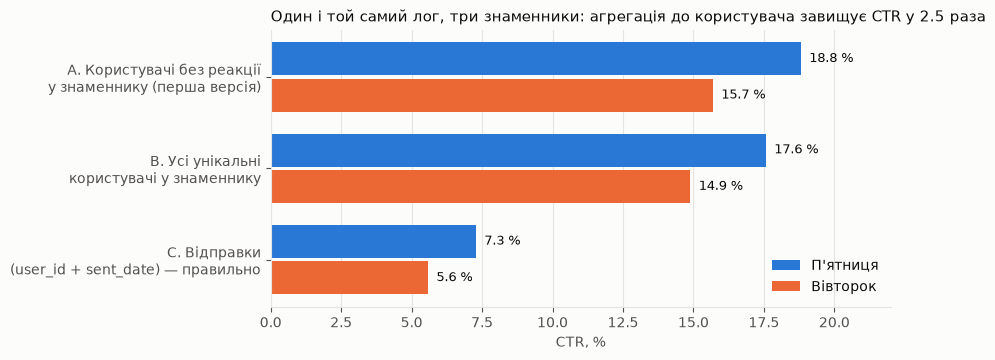

In [12]:
wrong_right = sql_file("07_wrong_vs_right.sql")[0]
display(wrong_right)

pivot = wrong_right.pivot(index="method", columns="send_day", values="ctr_pct")
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(pivot))
height = 0.36
for i, day in enumerate(["friday", "tuesday"]):
    bars = ax.barh(y + (i - 0.5) * (height + 0.04), pivot[day], height=height, color=COL[day], label=LAB[day])
    for bar, value in zip(bars, pivot[day]):
        ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f} %", va="center", fontsize=9, color=INK)
ax.set_yticks(y)
ax.set_yticklabels([
    "A. Користувачі без реакції\nу знаменнику (перша версія)",
    "B. Усі унікальні\nкористувачі у знаменнику",
    "C. Відправки\n(user_id + sent_date) — правильно",
])
ax.invert_yaxis()
ax.set_xlim(0, 22)
ax.set_xlabel("CTR, %")
ax.grid(axis="y", visible=False)
ax.set_title("Один і той самий лог, три знаменники: агрегація до користувача завищує CTR у 2.5 раза", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
fig.savefig(IMG / "06_user_vs_observation.png")
plt.show()

Користувач, який отримав 10 листів і клікнув один раз, у способах A/B рахується як «клікнув», а 9 проігнорованих відправок зникають.
CTR виходить 18.8 % замість 7.3 %, і різниця між днями роздувається з 1.7 до 3.1 п.п. Далі — тільки спосіб C.

## 4. Перевірка дизайну тесту

### 4.1 SRM — чи збалансовані групи за обсягом

In [13]:
n_fri = int((obs.send_day == "friday").sum())
n_tue = int((obs.send_day == "tuesday").sum())
chi2, p_srm = ab.srm_test(n_fri, n_tue)
print(f"Відправок: п'ятниця {n_fri:,}, вівторок {n_tue:,} | χ² = {chi2:.2f}, p = {p_srm:.3f} -> дисбалансу немає")
print(f"Користувачів: п'ятниця {obs[obs.fri == 1].user_id.nunique():,}, вівторок {obs[obs.fri == 0].user_id.nunique():,}")
print(pd.crosstab(obs.send_day, obs.notice_type, normalize="index").round(3))
print(pd.crosstab(obs.send_day, obs.wf_type, normalize="index").round(3))

Відправок: п'ятниця 17,710, вівторок 17,817 | χ² = 0.32, p = 0.570 -> дисбалансу немає
Користувачів: п'ятниця 4,109, вівторок 4,062
notice_type  email   push
send_day                 
friday       0.737  0.263
tuesday      0.734  0.266
wf_type   lessActivityThisMonth  lessActivityThisWeek
send_day                                             
friday                    0.551                 0.449
tuesday                   0.560                 0.440


Групи однакові за розміром і за складом (частка push і частка ThisMonth у них збігаються до третього знака), тобто різниця CTR
не пояснюється різним міксом каналів чи воркфлоу.

### 4.2 Потужність і мінімальний детектований ефект (MDE)

In [14]:
baseline = obs[obs.fri == 0].clicked.mean()
n_arm = min(n_fri, n_tue)
mde = ab.mde_absolute(baseline, n_arm)
print(f"База (вівторок) = {pp(baseline)}, n на групу = {n_arm:,}")
print(f"MDE при потужності 80 %: {mde * 100:.2f} п.п. (відносно {mde / baseline:.0%})")
for lift in [0.005, 0.01, 0.015]:
    power = NormalIndPower().power(proportion_effectsize(baseline + lift, baseline), nobs1=n_arm, alpha=0.05)
    print(f"  ефект {lift * 100:.1f} п.п. -> потужність {power:.0%}")
n_needed = ab.n_per_group_for_lift(baseline, 0.01)
weekly_volume = len(obs) / 13
print(f"Для MDE 1 п.п. за незалежних відправок потрібно ≈ {n_needed:,.0f} на групу: ~{n_needed / (weekly_volume / 2):.0f} тижнів "
      f"для двох гілок при ~{weekly_volume:,.0f} відправках на тиждень")

# кластеризація по користувачу: важлива для майбутнього тесту з рандомізацією по user_id
design = ab.icc_anova(obs, "user_id", "clicked")
n_needed_cluster = n_needed * design["deff"]
print(f"\nICC кліків усередині користувача = {design['icc']:.3f}, у середньому {design['avg_cluster_size']:.1f} відправок на користувача "
      f"-> design effect = {design['deff']:.2f} для рандомізації по користувачу")
print(f"Чистий тест з рандомізацією по user_id: MDE 1 п.п. потребує ≈ {n_needed_cluster:,.0f} відправок на гілку "
      f"(~{n_needed_cluster / (weekly_volume / 2):.0f} тижнів для двох гілок, ~{n_needed_cluster / (weekly_volume / 4):.0f} для чотирьох); "
      f"MDE при поточному обсязі = {ab.mde_absolute(baseline, int(n_arm / design['deff'])) * 100:.2f} п.п.")

База (вівторок) = 5.58 %, n на групу = 17,710
MDE при потужності 80 %: 0.70 п.п. (відносно 13%)
  ефект 0.5 п.п. -> потужність 52%
  ефект 1.0 п.п. -> потужність 98%
  ефект 1.5 п.п. -> потужність 100%
Для MDE 1 п.п. за незалежних відправок потрібно ≈ 8,956 на групу: ~7 тижнів для двох гілок при ~2,733 відправках на тиждень

ICC кліків усередині користувача = 0.218, у середньому 7.8 відправок на користувача -> design effect = 2.47 для рандомізації по користувачу
Чистий тест з рандомізацією по user_id: MDE 1 п.п. потребує ≈ 22,143 відправок на гілку (~16 тижнів для двох гілок, ~32 для чотирьох); MDE при поточному обсязі = 1.12 п.п.


Для **цього** порівняння вибірка достатня: ефект від 0.7 п.п. ми б помітили з потужністю 80 %, а фактична різниця (1.7 п.п.)
більша за MDE у 2.4 раза. Кластеризація тут майже не збільшує помилку (кластерна SE 0.248 проти наївної 0.260 п.п., розділ 6),
бо день змінюється **всередині** користувача.

Для **майбутнього** тесту з рандомізацією по `user_id` це не так: усі повідомлення користувача потраплять в одну гілку, а кліки
одного користувача сильно корельовані (ICC = 0.22). Design effect ≈ 2.5 означає, що потрібний обсяг зростає у 2.5 раза:
≈ 22 тис. відправок на гілку, тобто ~16 тижнів для двох гілок. Це прямо впливає на дизайн у розділі 9.4.

## 5. Основний тест: CTR по днях на рівні відправок

Запит `sql/02_ab_test_by_day.sql` рахує все, включно з z-статистикою, прямо в SQL; нижче те саме в Python з ДІ Вілсона.

In [15]:
display(sql_file("02_ab_test_by_day.sql")[0])

main = ab.rate_table(obs, "send_day").set_index("send_day")
res = ab.compare_groups(obs, "send_day", "friday", "tuesday")
shown = main.assign(rate=(main.rate * 100).round(2), ci_low=(main.ci_low * 100).round(2), ci_high=(main.ci_high * 100).round(2))
print(shown)
print(f"\nРізниця: {res.diff * 100:+.2f} п.п., 95% ДІ [{res.ci_low * 100:.2f}; {res.ci_high * 100:.2f}], відносно {res.relative:+.1%}")
print(f"z = {res.z:.2f}, p = {res.p:.1e}  ->  H0 відхиляємо")

,sent_friday,clicked_friday,ctr_friday_pct,sent_tuesday,clicked_tuesday,ctr_tuesday_pct,diff_pp,uplift_pct,diff_ci_low_pp,diff_ci_high_pp,z_stat
0,17710,1290.0,7.28,17817,995.0,5.58,1.7,30.4,1.19,2.21,6.53


           sent  users  success  rate  ci_low  ci_high
send_day                                              
friday    17710   4109     1290  7.28    6.91     7.68
tuesday   17817   4062      995  5.58    5.26     5.93

Різниця: +1.70 п.п., 95% ДІ [1.19; 2.21], відносно +30.4%
z = 6.53, p = 6.6e-11  ->  H0 відхиляємо


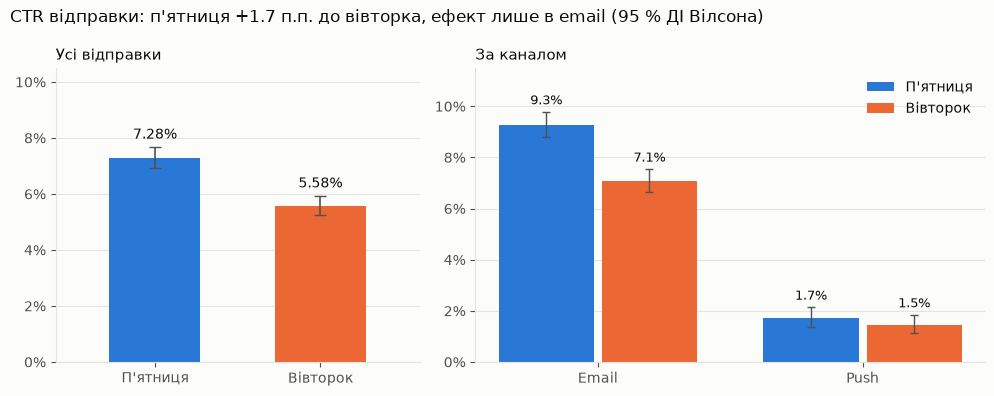

In [16]:
by_channel = ab.rate_table(obs, ["notice_type", "send_day"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1, 1.4]})

ax = axes[0]
for i, day in enumerate(["friday", "tuesday"]):
    row = main.loc[day]
    ax.bar(i, row.rate, width=0.55, color=COL[day])
    ax.errorbar(i, row.rate, yerr=[[row.rate - row.ci_low], [row.ci_high - row.rate]], fmt="none", ecolor=INK2, capsize=4, lw=1.2)
    ax.text(i, row.ci_high + 0.003, f"{row.rate:.2%}", ha="center", fontsize=10, color=INK)
ax.set_xticks([0, 1])
ax.set_xticklabels([LAB["friday"], LAB["tuesday"]])
ax.set_xlim(-0.6, 1.6)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 0.105)
ax.grid(axis="x", visible=False)
ax.set_title("Усі відправки", loc="left", fontsize=11)

ax = axes[1]
x = np.arange(2)
width = 0.36
for i, day in enumerate(["friday", "tuesday"]):
    rows = by_channel[by_channel.send_day == day].set_index("notice_type").loc[["email", "push"]]
    offset = x + (i - 0.5) * (width + 0.03)
    ax.bar(offset, rows.rate, width=width, color=COL[day], label=LAB[day])
    ax.errorbar(offset, rows.rate, yerr=[rows.rate - rows.ci_low, rows.ci_high - rows.rate], fmt="none", ecolor=INK2, capsize=3, lw=1)
    for xi, value, high in zip(offset, rows.rate, rows.ci_high):
        ax.text(xi, high + 0.003, f"{value:.1%}", ha="center", fontsize=9, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(["Email", "Push"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 0.115)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
ax.set_title("За каналом", loc="left", fontsize=11)

fig.suptitle("CTR відправки: п'ятниця +1.7 п.п. до вівторка, ефект лише в email (95 % ДІ Вілсона)", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig(IMG / "01_ctr_by_day.png")
plt.show()

## 6. Наскільки стійкий результат

### 6.1 Шість оцінок одного ефекту

Стандартний z-тест вважає всі 35 527 відправок незалежними, а це не так: один користувач дає в середньому 7.8 спостережень,
і його реакції корельовані (3.3). Тому переоцінюємо ефект способами, які по-різному враховують цю залежність:

1. **z-тест пропорцій** — базова оцінка (незалежні спостереження).
2. **Лінійна модель з кластерними SE по користувачу** — той самий ефект, чесна стандартна помилка.
3. **Кластерний бутстреп** — ресемплюємо користувачів цілком (2 000 повторів).
4. **Поправка на канал, воркфлоу і тиждень** — чи не пояснюється ефект складом груп.
5. **Порівняння всередині користувача** (fixed effects) — тільки ті 3 593 користувачі, що бачили обидва дні; кожен сам собі контроль.
6. **Парне порівняння по тижнях** — 12 повних тижнів як 12 пар.
7. **Двосторонні fixed effects** (користувач + тиждень) — прибирає ще й часовий тренд, зокрема березневе падіння.
8. **Двосторонні FE + попередній дотик + номер повідомлення** — чи не є «п'ятниця» просто першим або раннім повідомленням користувача.

In [17]:
clustered = ab.clustered_lpm(obs, "clicked ~ fri", "user_id")
boot = ab.cluster_bootstrap_diff(obs, "user_id", "fri", "clicked", n_boot=2000, seed=42)
adjusted = ab.clustered_lpm(obs, "clicked ~ fri + C(notice_type) + C(wf_type) + C(week)", "user_id")
within = ab.within_user_effect(obs, "user_id", "fri", "clicked")
full_weeks = obs[obs.week.between("2021-01-04", "2021-03-22")]
weekly = ab.paired_weekly_effect(full_weeks, "week", "fri", "clicked")
twoway = ab.two_way_fe_effect(obs, "user_id", "week", "fri", "clicked")
twoway_ctrl = ab.two_way_fe_effect(obs, "user_id", "week", "fri", "clicked", controls=("prior_touch_7d", "log_msg_no"))

rows = [
    ("1. z-тест пропорцій", res.diff, res.ci_low, res.ci_high, res.p),
    ("2. OLS, кластерні SE по user_id", clustered["coef"], clustered["ci_low"], clustered["ci_high"], clustered["p"]),
    ("3. Кластерний бутстреп (2 000)", boot["mean"], boot["ci_low"], boot["ci_high"], boot["share_below_zero"]),
    ("4. + канал, воркфлоу, тиждень", adjusted["coef"], adjusted["ci_low"], adjusted["ci_high"], adjusted["p"]),
    ("5. Всередині користувача (FE)", within["coef"], within["ci_low"], within["ci_high"], within["p"]),
    (f"6. Парне по тижнях (n = {weekly['weeks']})", weekly["mean"], weekly["ci_low"], weekly["ci_high"], weekly["p"]),
    ("7. FE користувач + тиждень", twoway["coef"], twoway["ci_low"], twoway["ci_high"], twoway["p"]),
    ("8. FE + тиждень + дотик + номер повідомлення", twoway_ctrl["coef"], twoway_ctrl["ci_low"], twoway_ctrl["ci_high"], twoway_ctrl["p"]),
]
robust = pd.DataFrame(rows, columns=["метод", "ефект", "ДІ low", "ДІ high", "p"])


def format_p(value, is_bootstrap):
    if is_bootstrap:
        return f"< 1/{boot['n_boot']}" if value == 0 else f"{value:.4f}"
    return f"{value:.1e}" if value < 0.001 else f"{value:.3f}"


shown = robust.copy()
for column in ["ефект", "ДІ low", "ДІ high"]:
    shown[column] = (shown[column] * 100).round(2)
shown["p"] = [format_p(v, i == 2) for i, v in enumerate(shown.p)]
display(shown.rename(columns={"ефект": "ефект, п.п.", "ДІ low": "95% ДІ від", "ДІ high": "95% ДІ до",
                              "p": "p (для бутстрепа — частка повторів ≤ 0)"}))

logit = smf.logit("clicked ~ fri", obs).fit(disp=0, cov_type="cluster", cov_kwds={"groups": obs.user_id})
print(f"Логіт з кластерними SE: OR = {np.exp(logit.params['fri']):.2f}")

,метод,"ефект, п.п.",95% ДІ від,95% ДІ до,p (для бутстрепа — частка повторів ≤ 0)
0,1. z-тест пропорцій,1.70,1.19,2.21,6.6e-11
1,"2. OLS, кластерні SE по user_id",1.70,1.21,2.18,6.7e-12
2,3. Кластерний бутстреп (2 000),1.70,1.19,2.18,< 1/2000
3,"4. + канал, воркфлоу, тиждень",1.59,1.09,2.09,5.1e-10
4,5. Всередині користувача (FE),1.82,1.33,2.30,1.9e-13
5,6. Парне по тижнях (n = 12),1.45,0.22,2.69,0.025
6,7. FE користувач + тиждень,1.56,1.07,2.06,6.9e-10
7,8. FE + тиждень + дотик + номер повідомлення,1.39,0.89,1.90,6.2e-08


Логіт з кластерними SE: OR = 1.33


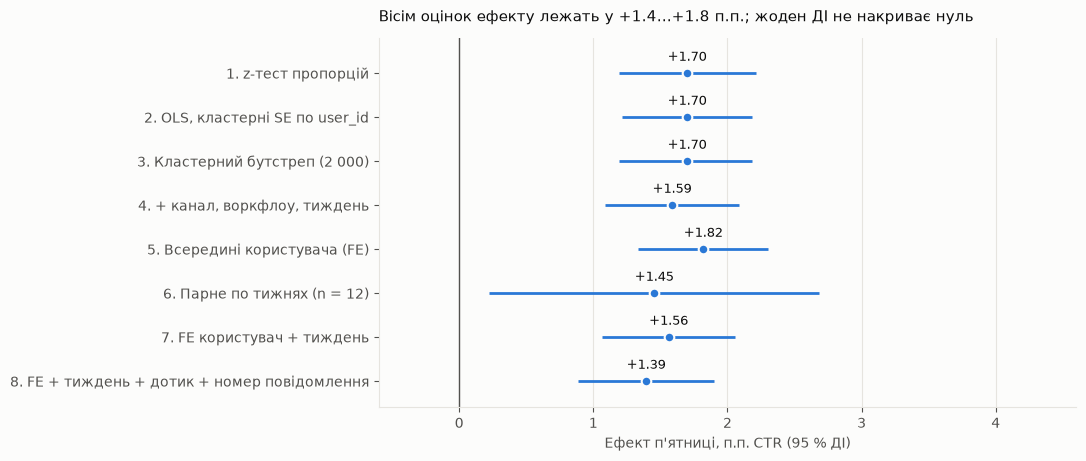

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ypos = np.arange(len(robust))[::-1]
ax.axvline(0, color=INK2, lw=1)
ax.hlines(ypos, robust["ДІ low"] * 100, robust["ДІ high"] * 100, color=BLUE, lw=2)
ax.scatter(robust["ефект"] * 100, ypos, color=BLUE, s=48, zorder=3, edgecolor=SURF, linewidth=1.5)
for yi, value in zip(ypos, robust["ефект"] * 100):
    ax.text(value, yi + 0.28, f"{value:+.2f}", ha="center", fontsize=9, color=INK)
ax.set_yticks(ypos)
ax.set_yticklabels(robust["метод"])
ax.set_xlabel("Ефект п'ятниці, п.п. CTR (95 % ДІ)")
ax.set_xlim(-0.6, 4.6)
ax.set_ylim(-0.6, len(robust) - 0.2)
ax.grid(axis="y", visible=False)
ax.set_title("Вісім оцінок ефекту лежать у +1.4…+1.8 п.п.; жоден ДІ не накриває нуль", loc="left", fontsize=11, pad=12)
fig.savefig(IMG / "03_robustness.png")
plt.show()

**Чому оцінка всередині користувача (+1.82) більша за пулову (+1.70)?** Не через склад вибірки: серед 3 593 користувачів
з обома днями пулова різниця становить +1.68 п.п., серед 985 користувачів з одним днем — +2.29 п.п. (їх лише 1 378 відправок).
Різниця виникає зі **зважування**: FE зважує кожного користувача за балансом його відправок між днями і повністю прибирає
різницю базових CTR між людьми, тоді як пулова оцінка зважує кожну відправку однаково. Базовий CTR користувача практично
не корелює з його часткою п'ятничних відправок (r ≈ 0), тому це не зміщення, а різні ваги, і обидві оцінки лежать у ДІ одна одної.

**Двосторонні FE (рядки 7–8).** Якщо до користувача додати ще й тиждень, ефект стає +1.56 п.п. [1.07; 2.06]: частина переваги
п'ятниці в простому within-user порівнянні — часовий тренд (п'ятничних відправок було відносно більше в «сильні» тижні).
Якщо додатково врахувати попередній дотик і порядковий номер повідомлення — +1.39 п.п. [0.89; 1.90]: п'ятниця частіше була
**першим** повідомленням користувача (1 січня — п'ятниця: 2 536 перших повідомлень проти 2 042 у вівторка), а перше
повідомлення клікають краще за десяте. Це найконсервативніша оцінка, і вона все ще далека від нуля.

In [19]:
days_per_user = obs.groupby("user_id").send_day.transform("nunique")
both_days = obs[days_per_user == 2]
single_day = obs[days_per_user == 1]
pooled_both = ab.compare_groups(both_days, "send_day", "friday", "tuesday")
pooled_single = ab.compare_groups(single_day, "send_day", "friday", "tuesday")
print(f"Користувачі з обома днями: {both_days.user_id.nunique():,} осіб, {len(both_days):,} відправок, "
      f"пулова різниця {pooled_both.diff * 100:+.2f} п.п., within-user {within['coef'] * 100:+.2f} п.п.")
print(f"Користувачі з одним днем: {single_day.user_id.nunique():,} осіб, {len(single_day):,} відправок, "
      f"різниця {pooled_single.diff * 100:+.2f} п.п.")
user_stats = both_days.groupby("user_id").agg(fri_share=("fri", "mean"), ctr=("clicked", "mean"))
print(f"Кореляція «частка п'ятничних відправок користувача» × «його базовий CTR»: r = {np.corrcoef(user_stats.fri_share, user_stats.ctr)[0, 1]:+.3f}")

Користувачі з обома днями: 3,593 осіб, 34,149 відправок, пулова різниця +1.68 п.п., within-user +1.82 п.п.
Користувачі з одним днем: 985 осіб, 1,378 відправок, різниця +2.29 п.п.
Кореляція «частка п'ятничних відправок користувача» × «його базовий CTR»: r = +0.002


### 6.2 Інтерференція: чи п'ятниця виграє лише як «другий дотик»?

38 % користувач-тижнів отримали обидва дні, і п'ятничний лист тоді приходить через три дні після вівторкового. Якщо другий дотик
за тиждень сам по собі підвищує клік, перевага п'ятниці була б артефактом послідовності, а не дня. Перевіряємо трьома способами:
(1) стратифікація за наявністю попереднього повідомлення за 7 днів, (2) лише тижні з одним днем, (3) модель із взаємодією.

In [20]:
print("Частка відправок, перед якими було інше повідомлення за ≤ 7 днів:",
      obs.groupby("send_day").prior_touch_7d.mean().round(3).to_dict())

strata = ab.rate_table(obs, ["prior_touch_7d", "send_day"])
strata["rate"] = (strata.rate * 100).round(2)
display(strata[["prior_touch_7d", "send_day", "sent", "success", "rate"]].rename(columns={"rate": "ctr_pct"}))
for flag, label in [(0, "без попереднього дотику"), (1, "після дотику за ≤ 7 днів")]:
    r = ab.compare_groups(obs[obs.prior_touch_7d == flag], "send_day", "friday", "tuesday")
    print(f"{label:<26}: {r.diff * 100:+.2f} п.п. [{r.ci_low * 100:.2f}; {r.ci_high * 100:.2f}], p = {r.p:.1e}")

days_in_week = obs.groupby(["user_id", "week"]).send_day.transform("nunique")
single_touch = ab.compare_groups(obs[days_in_week == 1], "send_day", "friday", "tuesday")
double_touch = ab.compare_groups(obs[days_in_week == 2], "send_day", "friday", "tuesday")
print(f"Тижні з одним днем  : п'ятниця {pp(single_touch.rate_a)} vs вівторок {pp(single_touch.rate_b)}, "
      f"{single_touch.diff * 100:+.2f} п.п., p = {single_touch.p:.1e} (n = {single_touch.n_a + single_touch.n_b:,})")
print(f"Тижні з обома днями : п'ятниця {pp(double_touch.rate_a)} vs вівторок {pp(double_touch.rate_b)}, "
      f"{double_touch.diff * 100:+.2f} п.п., p = {double_touch.p:.1e} (n = {double_touch.n_a + double_touch.n_b:,})")

interaction = ab.clustered_lpm(obs, "clicked ~ fri * prior_touch_7d", "user_id", term="fri:prior_touch_7d")
print(f"Взаємодія «день × попередній дотик»: {interaction['coef'] * 100:+.2f} п.п., p = {interaction['p']:.2f}")

Частка відправок, перед якими було інше повідомлення за ≤ 7 днів: {'friday': 0.643, 'tuesday': 0.612}


,prior_touch_7d,send_day,sent,success,ctr_pct
0,0,friday,6328,479,7.57
1,0,tuesday,6906,402,5.82
2,1,friday,11382,811,7.13
3,1,tuesday,10911,593,5.43


без попереднього дотику   : +1.75 п.п. [0.89; 2.60], p = 5.6e-05
після дотику за ≤ 7 днів  : +1.69 п.п. [1.05; 2.33], p = 2.1e-07
Тижні з одним днем  : п'ятниця 7.39 % vs вівторок 5.65 %, +1.74 п.п., p = 8.3e-06 (n = 15,908)
Тижні з обома днями : п'ятниця 7.20 % vs вівторок 5.53 %, +1.67 п.п., p = 1.8e-06 (n = 19,619)
Взаємодія «день × попередній дотик»: -0.06 п.п., p = 0.92


**Висновок з 6.2.** Ефект п'ятниці однаковий там, де попереднього дотику не було (+1.75 п.п.), і там, де він був (+1.69 п.п.);
у тижнях з одним днем він такий самий, як у тижнях з обома (+1.74 vs +1.67); взаємодія дорівнює нулю (p = 0.92).
Сам попередній дотик трохи знижує CTR (−0.4 п.п., p = 0.29 — у межах шуму). Отже інтерференція не пояснює результат — п'ятниця
виграє і як перший, і як другий дотик.

In [21]:
# додатково: без бот-подібних користувачів (>= 30 кліків за період)
bots = obs.groupby("user_id").n_click.sum().pipe(lambda s: s[s >= 30].index)
no_bots = ab.compare_groups(obs[~obs.user_id.isin(bots)], "send_day", "friday", "tuesday")
print(f"Без {len(bots)} аномальних користувачів: п'ятниця {pp(no_bots.rate_a)}, вівторок {pp(no_bots.rate_b)}, "
      f"z = {no_bots.z:.2f}, p = {no_bots.p:.1e}")

# within-user: частка користувачів, у яких п'ятниця краща / гірша / однакова
user_rates = both_days.groupby(["user_id", "send_day"]).clicked.mean().unstack()
print(f"Серед {len(user_rates):,} користувачів з обома днями: п'ятниця краща у {(user_rates.friday > user_rates.tuesday).mean():.1%}, "
      f"вівторок кращий у {(user_rates.tuesday > user_rates.friday).mean():.1%}, однаково (переважно 0 = 0) у "
      f"{(user_rates.friday == user_rates.tuesday).mean():.1%}; Вілкоксон p = {stats.wilcoxon(user_rates.friday, user_rates.tuesday).pvalue:.1e}")

Без 18 аномальних користувачів: п'ятниця 6.99 %, вівторок 5.35 %, z = 6.41, p = 1.5e-10
Серед 3,593 користувачів з обома днями: п'ятниця краща у 14.3%, вівторок кращий у 9.3%, однаково (переважно 0 = 0) у 76.4%; Вілкоксон p = 1.8e-11


**Висновок з блоку 6.** Ефект п'ятниці не є артефактом залежних спостережень, складу груп, часового тренду, позиції повідомлення
в послідовності, інтерференції чи кількох аномальних користувачів: усі вісім оцінок лежать у діапазоні +1.4…+1.8 п.п., і навіть
найконсервативніші (парне порівняння по 12 тижнях і FE з поправкою на тиждень, дотик і номер повідомлення) значущі на рівні 0.05.
Найпереконливіша — порівняння всередині користувача: одна й та сама людина частіше клікає на п'ятничне повідомлення.

## 7. Розрізи та динаміка

### 7.1 Канал і воркфлоу

In [22]:
by_channel_sql, by_workflow_sql, _ = sql_file("03_segments.sql")
display(by_channel_sql)
display(by_workflow_sql)

for column, values in [("notice_type", ["email", "push"]), ("wf_type", ["lessActivityThisWeek", "lessActivityThisMonth"])]:
    for value in values:
        r = ab.compare_groups(obs[obs[column] == value], "send_day", "friday", "tuesday")
        print(f"{column}={value}: п'ятниця {pp(r.rate_a)} vs вівторок {pp(r.rate_b)}, z = {r.z:.2f}, p = {r.p:.3g}")

email = obs[obs.notice_type == "email"]
open_rate = ab.compare_groups(email, "send_day", "friday", "tuesday", y="opened")
print(f"Email open rate: п'ятниця {pp(open_rate.rate_a)} vs вівторок {pp(open_rate.rate_b)}, p = {open_rate.p:.1e}")
ctor = ab.compare_groups(email[email.opened == 1], "send_day", "friday", "tuesday")
print(f"Email CTOR (клік | відкрив): п'ятниця {pp(ctor.rate_a, 1)} vs вівторок {pp(ctor.rate_b, 1)}, p = {ctor.p:.1e}")

,notice_type,send_day,sent,users,opened,clicked,open_rate_pct,ctr_pct,ctor_pct
0,email,friday,13057,3702,2603.0,1210.0,19.94,9.27,46.5
1,email,tuesday,13073,3650,2241.0,926.0,17.14,7.08,41.3
2,push,friday,4653,1737,0.0,80.0,0.00,1.72,NaN
3,push,tuesday,4744,1791,0.0,69.0,0.00,1.45,NaN


,wf_type,send_day,sent,clicked,ctr_pct
0,lessActivityThisMonth,friday,9760,675.0,6.92
1,lessActivityThisMonth,tuesday,9969,510.0,5.12
2,lessActivityThisWeek,friday,7950,615.0,7.74
3,lessActivityThisWeek,tuesday,7848,485.0,6.18


notice_type=email: п'ятниця 9.27 % vs вівторок 7.08 %, z = 6.44, p = 1.18e-10
notice_type=push: п'ятниця 1.72 % vs вівторок 1.45 %, z = 1.03, p = 0.304
wf_type=lessActivityThisWeek: п'ятниця 7.74 % vs вівторок 6.18 %, z = 3.84, p = 0.000122
wf_type=lessActivityThisMonth: п'ятниця 6.92 % vs вівторок 5.12 %, z = 5.32, p = 1.04e-07
Email open rate: п'ятниця 19.94 % vs вівторок 17.14 %, p = 6.2e-09
Email CTOR (клік | відкрив): п'ятниця 45.0 % vs вівторок 39.8 %, p = 2.2e-04


**Множинні порівняння.** Первинна гіпотеза одна (розділ 5). Сегментні тести — сімейство пошукових перевірок, тому нижче
поправка Холма для всіх восьми і, коректніше, тест на взаємодію «день × сегмент»: він відповідає на питання «чи різний ефект
між сегментами», а не «чи є ефект у кожному сегменті окремо».

In [23]:
family = {}
for column, values in [("notice_type", ["email", "push"]), ("wf_type", ["lessActivityThisWeek", "lessActivityThisMonth"]),
                       ("period", ["січень–лютий", "березень"]), ("prior_touch_7d", [0, 1])]:
    for value in values:
        family[f"{column}={value}"] = ab.compare_groups(obs[obs[column] == value], "send_day", "friday", "tuesday").p
holm = ab.holm_adjust(family)
display(holm.assign(p_raw=holm.p_raw.map("{:.2e}".format), p_holm=holm.p_holm.map("{:.2e}".format)))
for column in ["notice_type", "wf_type", "period", "prior_touch_7d"]:
    het = ab.heterogeneity_test(obs, "fri", column, "clicked", "user_id")
    print(f"Чи різний ефект дня між сегментами {column:<15}: p = {het['p']:.3g}")

,test,p_raw,p_holm,significant_holm
0,notice_type=email,1.18e-10,8.24e-10,True
1,notice_type=push,3.04e-01,6.08e-01,False
2,wf_type=lessActivityThisWeek,1.22e-04,3.66e-04,True
3,wf_type=lessActivityThisMonth,1.04e-07,6.21e-07,True
4,period=січень–лютий,1.22e-11,9.78e-11,True
5,period=березень,8.58e-01,8.58e-01,False
6,prior_touch_7d=0,5.56e-05,2.22e-04,True
7,prior_touch_7d=1,2.06e-07,1.03e-06,True


Чи різний ефект дня між сегментами notice_type    : p = 1.67e-06
Чи різний ефект дня між сегментами wf_type        : p = 0.611
Чи різний ефект дня між сегментами period         : p = 3.13e-05


Чи різний ефект дня між сегментами prior_touch_7d : p = 0.916


Після поправки Холма жоден висновок не змінюється. Тести на взаємодію підтверджують картину: ефект дня **різний** між каналами
(p < 0.001) і між періодами (p < 0.001), **однаковий** між воркфлоу (p = 0.61) і між наявністю чи відсутністю попереднього дотику (p = 0.92).

* **Email:** п'ятниця краща і за відкриттями (19.9 % vs 17.1 %), і за кліками (9.3 % vs 7.1 %), і за CTOR (45 % vs 40 %) —
  тобто п'ятничний лист і частіше відкривають, і частіше клікають після відкриття.
* **Push:** 1.7 % vs 1.5 %, p = 0.30 — різниці немає. Push сам по собі дає у 5 разів менше кліків за email.
* Обидва воркфлоу показують однаковий напрям ефекту (+1.6…+1.8 п.п.).

### 7.2 Динаміка по тижнях

In [24]:
weekly_sql = sql_file("04_weekly.sql")[0]
display(weekly_sql)
print(f"Тижнів з перевагою п'ятниці: {weekly['wins']} з {weekly['weeks']}; парний t-тест p = {weekly['p']:.3f}; "
      f"знаковий тест p = {weekly['sign_test_p']:.2f}")

for period_name, part in obs.groupby("period"):
    r = ab.compare_groups(part, "send_day", "friday", "tuesday")
    print(f"{period_name}: п'ятниця {pp(r.rate_a)} vs вівторок {pp(r.rate_b)} (n = {r.n_a + r.n_b:,}), z = {r.z:.2f}, p = {r.p:.3g}")

,week_start,sent_friday,sent_tuesday,ctr_friday_pct,ctr_tuesday_pct,diff_pp
0,2020-12-28,1559.0,0.0,8.40,NaN,NaN
1,2021-01-04,1655.0,1734.0,8.88,5.42,3.46
2,2021-01-11,1531.0,1611.0,7.97,6.39,1.58
3,2021-01-18,1399.0,1351.0,7.29,6.96,0.33
4,2021-01-25,1543.0,1463.0,9.66,5.47,4.19
5,2021-02-01,1331.0,1502.0,5.48,5.53,-0.04
6,2021-02-08,1238.0,1263.0,7.84,5.15,2.69
7,2021-02-15,1430.0,1323.0,5.52,5.82,-0.30
8,2021-02-22,1267.0,1311.0,6.39,5.57,0.82
9,2021-03-01,1237.0,1321.0,10.59,5.45,5.14


Тижнів з перевагою п'ятниці: 8 з 12; парний t-тест p = 0.025; знаковий тест p = 0.39
березень: п'ятниця 5.06 % vs вівторок 5.14 % (n = 8,458), z = -0.18, p = 0.858
січень–лютий: п'ятниця 7.84 % vs вівторок 5.75 % (n = 27,069), z = 6.78, p = 1.22e-11


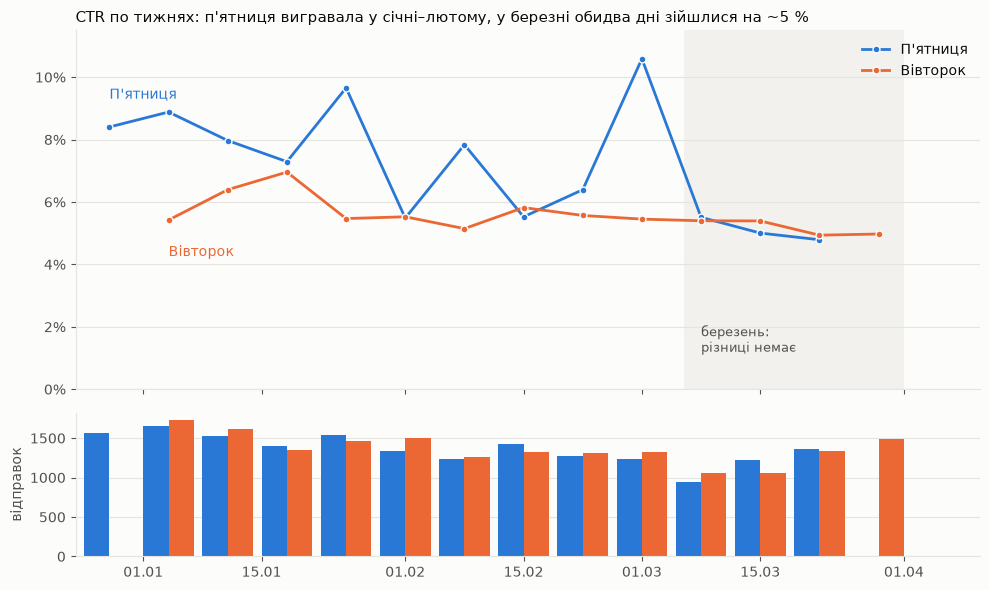

In [25]:
weekly_rates = obs.groupby(["week", "send_day"]).agg(ctr=("clicked", "mean"), sent=("clicked", "size")).reset_index()
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
for day in ["friday", "tuesday"]:
    part = weekly_rates[weekly_rates.send_day == day]
    ax.plot(part.week, part.ctr, color=COL[day], lw=2, marker="o", ms=5, markeredgecolor=SURF, label=LAB[day])
    dy = 0.008 if day == "friday" else -0.008
    ax.text(part.week.iloc[0], part.ctr.iloc[0] + dy, LAB[day], color=COL[day], ha="left", va="bottom" if dy > 0 else "top", fontsize=10)
ax.axvspan(pd.Timestamp("2021-03-06"), pd.Timestamp("2021-04-01"), color=GRID, alpha=0.45, lw=0)
ax.text(pd.Timestamp("2021-03-08"), 0.012, "березень:\nрізниці немає", fontsize=9, color=INK2)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 0.115)
ax.grid(axis="x", visible=False)
ax.set_title("CTR по тижнях: п'ятниця вигравала у січні–лютому, у березні обидва дні зійшлися на ~5 %", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper right")
for i, day in enumerate(["friday", "tuesday"]):
    part = weekly_rates[weekly_rates.send_day == day]
    ax2.bar(part.week + pd.Timedelta(days=1.5 if i else -1.5), part.sent, width=3, color=COL[day])
ax2.set_ylabel("відправок")
ax2.grid(axis="x", visible=False)
ax2.xaxis.set_major_formatter(mpl.dates.DateFormatter("%d.%m"))
ax2.set_xlim(pd.Timestamp("2020-12-24"), pd.Timestamp("2021-04-10"))
fig.tight_layout()
fig.savefig(IMG / "02_weekly_ctr.png")
plt.show()

**Це головний нюанс результату.** Середній ефект +1.7 п.п. складається з сильної переваги п'ятниці в січні–лютому (+2.1 п.п., p < 0.001)
і **повної відсутності різниці в березні** (5.1 % vs 5.1 %, p = 0.86, 8.5 тис. відправок). Загальний CTR теж падає з ~8 % до ~5 %.
Чесно кажучи про тижневу картину: парний t-тест по 12 тижнях значущий (p = 0.025), але знаковий тест (8 з 12 тижнів) — ні (p = 0.39).
Тобто перевага п'ятниці — це кілька дуже сильних тижнів (+3…+5 п.п.), а не стабільна щотижнева різниця.
Можливі причини березневого вирівнювання: (а) вигорання аудиторії — до березня більшість користувачів отримали 10+ повідомлень,
і саме серед них різниці між днями майже немає (8.1); (б) зміна контенту або аудиторії, яку в логу не видно; (в) сезонність.
Що саме — з цих даних не сказати, і це перша причина рекомендувати повторний чистий тест.

## 8. Додаткові інсайти для оцінки розсилок

### 8.1 Втома: CTR падає з кожним наступним повідомленням

,msg_bucket,bucket_order,sent,users,ctr_pct,ctr_friday_pct,ctr_tuesday_pct
0,1,1,4578,4578,7.23,8.44,5.73
1,2,2,3894,3894,7.40,9.35,5.49
2,3,3,3233,3233,6.22,6.49,5.96
3,4-5,4,5409,2906,7.08,8.42,5.71
4,6-10,6,9191,2248,6.67,7.09,6.26
5,11-20,11,7431,1295,5.19,5.58,4.84
6,21+,21,1791,270,4.63,5.09,4.24


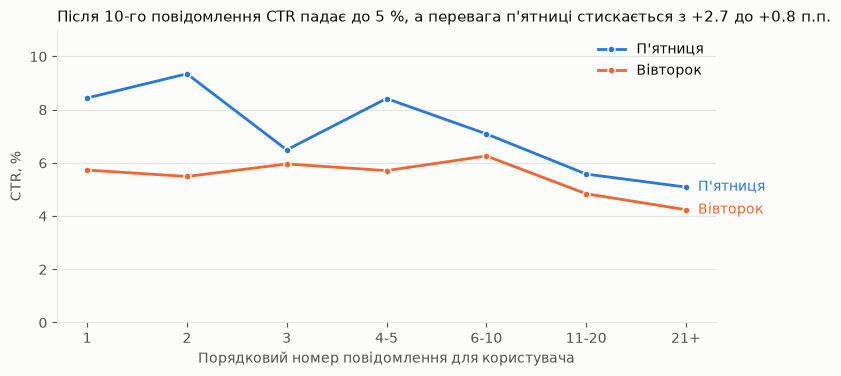

Частка відправок, які припадають на 11-те і далі повідомлення користувачу: 26.0%


In [26]:
fatigue = sql_file("05_fatigue.sql")[0]
display(fatigue)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
x = np.arange(len(fatigue))
for day in ["friday", "tuesday"]:
    ax.plot(x, fatigue[f"ctr_{day}_pct"], color=COL[day], lw=2, marker="o", ms=5, markeredgecolor=SURF, label=LAB[day])
    ax.text(x[-1] + 0.12, fatigue[f"ctr_{day}_pct"].iloc[-1], LAB[day], color=COL[day], va="center")
ax.set_xticks(x)
ax.set_xticklabels(fatigue.msg_bucket)
ax.set_xlabel("Порядковий номер повідомлення для користувача")
ax.set_ylabel("CTR, %")
ax.set_ylim(0, 11)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
ax.set_title("Після 10-го повідомлення CTR падає до 5 %, а перевага п'ятниці стискається з +2.7 до +0.8 п.п.", loc="left", fontsize=11)
fig.savefig(IMG / "04_fatigue.png")
plt.show()
print(f"Частка відправок, які припадають на 11-те і далі повідомлення користувачу: {(obs.msg_no > 10).mean():.1%}")

### 8.2 Час реакції

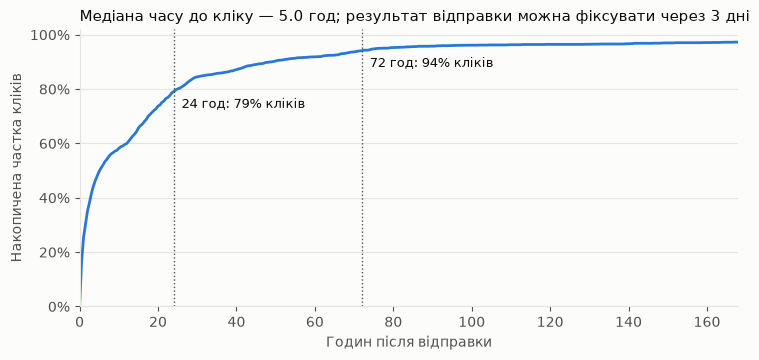

Частка кліків у першу годину після відправки: {"П'ятниця": '22%', 'Вівторок': '30%'}


In [27]:
clicks_h = obs.loc[obs.clicked == 1, "tt_click_h"].sort_values().values
grid_h = np.linspace(0, 168, 337)
ecdf = np.searchsorted(clicks_h, grid_h, side="right") / len(clicks_h)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(grid_h, ecdf, color=BLUE, lw=2)
for hours, label in [(24, "24 год"), (72, "72 год")]:
    share = np.searchsorted(clicks_h, hours, side="right") / len(clicks_h)
    ax.axvline(hours, color=INK2, lw=1, ls=":")
    ax.text(hours + 2, share - 0.06, f"{label}: {share:.0%} кліків", fontsize=9, color=INK)
ax.set_xlim(0, 168)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Годин після відправки")
ax.set_ylabel("Накопичена частка кліків")
ax.grid(axis="x", visible=False)
ax.set_title(f"Медіана часу до кліку — {np.median(clicks_h):.1f} год; результат відправки можна фіксувати через 3 дні", loc="left", fontsize=11)
fig.savefig(IMG / "05_time_to_click.png")
plt.show()

first_hour = obs[obs.clicked == 1].groupby("send_day").tt_click_h.apply(lambda s: (s <= 1).mean())
print("Частка кліків у першу годину після відправки:", {LAB[k]: f"{v:.0%}" for k, v in first_hour.items()})

### 8.3 CTR — проксі. Що лог каже про реактивацію

Мета воркфлоу `lessActivity…` — повернути користувача в продукт, а не отримати клік. Даних про активність після розсилки немає,
але є непрямий сигнал: **повідомлення приходить лише тим, у кого активність падає**. Якщо клік реально повертає людину в продукт,
через тиждень вона не мала б знову потрапити в тригер. Перевіряємо: чи рідше отримують наступне повідомлення ті, хто клікнув?
(Відправки з останніх N днів виключено, щоб не було цензурування справа.)

In [28]:
obs["react"] = np.select([obs.clicked == 1, obs.opened == 1], ["клік", "відкрив, не клікнув"], "без реакції")
max_date = obs.sent_date.max()
rows = []
for horizon in [7, 14, 21]:
    window = obs[obs.sent_date <= max_date - pd.Timedelta(days=horizon)].copy()
    # ціла кількість днів: повідомлення рівно через тиждень (7 днів і кілька хвилин) рахуємо як «за 7 днів»
    window["retrig"] = (np.floor(window.days_to_next) <= horizon).astype(int)
    r = ab.compare_groups(window, "clicked", 1, 0, y="retrig")
    print(f"{horizon:>2} днів: нове повідомлення отримали {pp(r.rate_a, 1)} тих, хто клікнув (n = {r.n_a:,}), "
          f"і {pp(r.rate_b, 1)} тих, хто ні (n = {r.n_b:,}); z = {r.z:.2f}, p = {r.p:.3f}")
    for reaction, group in window.groupby("react"):
        rows.append((horizon, reaction, len(group), group.retrig.mean()))
retrigger = pd.DataFrame(rows, columns=["горизонт", "реакція", "відправок", "частка"])
display(retrigger.pivot(index="реакція", columns="горизонт", values="частка").round(3).rename(columns=lambda h: f"{h} днів"))

 7 днів: нове повідомлення отримали 65.6 % тих, хто клікнув (n = 2,119), і 65.6 % тих, хто ні (n = 30,202); z = 0.05, p = 0.963
14 днів: нове повідомлення отримали 81.5 % тих, хто клікнув (n = 2,019), і 78.3 % тих, хто ні (n = 28,107); z = 3.31, p = 0.001
21 днів: нове повідомлення отримали 85.9 % тих, хто клікнув (n = 1,876), і 83.8 % тих, хто ні (n = 25,701); z = 2.38, p = 0.017


горизонт,7 днів,14 днів,21 днів
реакція,,,
без реакції,0.657,0.783,0.838
"відкрив, не клікнув",0.649,0.793,0.847
клік,0.656,0.815,0.859


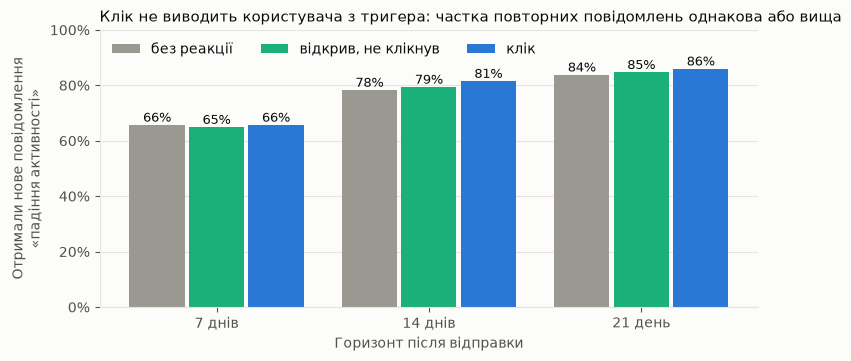

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
categories = [("без реакції", GRAY), ("відкрив, не клікнув", AQUA), ("клік", BLUE)]
x = np.arange(3)
width = 0.26
for i, (category, colour) in enumerate(categories):
    part = retrigger[retrigger["реакція"] == category].sort_values("горизонт")
    bars = ax.bar(x + (i - 1) * (width + 0.02), part["частка"], width=width, color=colour, label=category)
    for bar, value in zip(bars, part["частка"]):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.0%}", ha="center", fontsize=9, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(["7 днів", "14 днів", "21 день"])
ax.set_xlabel("Горизонт після відправки")
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(axis="x", visible=False)
ax.set_ylabel("Отримали нове повідомлення\n«падіння активності»")
ax.set_title("Клік не виводить користувача з тригера: частка повторних повідомлень однакова або вища", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper left", ncol=3)
fig.savefig(IMG / "07_retrigger.png")
plt.show()

**Висновок.** Через 7 днів нове повідомлення «активність падає» отримують 65.6 % тих, хто клікнув, і 65.6 % тих, хто не клікнув;
через 14 днів клікери отримують його навіть частіше (81.5 % vs 78.3 %). Тобто клік не супроводжується виходом із «згасаючої» когорти.

Це не доказ, що розсилка не працює (логіку тригера ми не знаємо, і ті, хто пішов назавжди, теж перестають отримувати повідомлення),
але це достатня причина **не використовувати CTR як міру успіху реактивації**. Для відповіді на питання «п'ятниця повертає більше
людей?» потрібні події активності в продукті та holdout-група.

### 8.4 День чи час, чи вихідні? Підказка з часу кліків

День і година відправки змішані (1), але час *кліку* дає підказку, за рахунок чого п'ятниця виграє.

In [30]:
clicked = obs[obs.clicked == 1].copy()
clicked["same_day"] = clicked.first_click.dt.date == clicked.sent_date.dt.date
sent_by_day = obs.groupby("send_day").size()
split = pd.DataFrame({
    "клік у день відправки": clicked[clicked.same_day].groupby("send_day").size() / sent_by_day,
    "клік у наступні дні": clicked[~clicked.same_day].groupby("send_day").size() / sent_by_day,
}).loc[["friday", "tuesday"]]
display((split * 100).round(2).rename(columns=lambda s: s + ", % відправок"))
edge = (split.loc["friday"] - split.loc["tuesday"]) * 100
print(f"Перевага п'ятниці: у день відправки {edge.iloc[0]:+.2f} п.п., у наступні дні {edge.iloc[1]:+.2f} п.п. "
      f"({edge.iloc[1] / edge.sum():.0%} усієї різниці — кліки після дня відправки)")
weekday_share = pd.crosstab(clicked.send_day, clicked.first_click.dt.day_name(), normalize="index")
display((weekday_share[["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Monday"]] * 100).round(1))

,"клік у день відправки, % відправок","клік у наступні дні, % відправок"
send_day,,
friday,3.89,3.39
tuesday,3.39,2.19


Перевага п'ятниці: у день відправки +0.50 п.п., у наступні дні +1.20 п.п. (71% усієї різниці — кліки після дня відправки)


first_click,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Monday
send_day,,,,,,,
friday,0.9,0.3,0.5,54.3,32.9,7.3,3.8
tuesday,61.6,23.9,6.7,5.0,1.2,0.4,1.1


У день відправки п'ятниця випереджає вівторок лише на 0.5 п.п., а в наступні дні — на 1.2 п.п.: 40 % п'ятничних кліків припадає на
суботу–неділю. Правдоподібна гіпотеза — **лист читають у вихідні**, а не «о 16:00 краще, ніж о 14:00». Але це саме гіпотеза для
дизайну 2×2, а не висновок.

### 8.5 Вибір одного дня — це ще й зміна частоти

In [31]:
per_user_week = obs.groupby(["user_id", "week"]).agg(n=("sent_date", "size"), days=("send_day", "nunique"))
now = per_user_week.n.mean()
one_day = (per_user_week.n / per_user_week.days).mean()
print(f"Повідомлень на користувача за тиждень зараз: {now:.2f}; якщо лишити лише один день: {one_day:.2f} (−{1 - one_day / now:.0%})")

Повідомлень на користувача за тиждень зараз: 1.72; якщо лишити лише один день: 1.25 (−28%)


Відключення одного з днів саме по собі зменшить частоту контактів на 28 %. З огляду на втому (8.1) це, ймовірно, підвищить CTR
кожної окремої відправки незалежно від того, який день лишити, і це теж треба закласти в очікування від рішення.

## 9. Висновки: що доведено, чого ні, і що робити

### 9.1 Що доведено

* На 35 527 відправках за 13 тижнів п'ятничні повідомлення клікали частіше: 7.28 % vs 5.58 %, **+1.70 п.п.** [1.19; 2.21], +30 %.
  Вісім способів оцінки, включно з двосторонніми fixed effects з поправкою на номер повідомлення, дають +1.4…+1.8 п.п.
* Групи збалансовані за обсягом і складом; призначення дня не залежить від попередньої реакції; інтерференція «другого дотику»
  не пояснює ефект; без 18 аномальних користувачів результат той самий.

### 9.2 Чого дані не доводять

| Проблема | Що це означає для рішення |
|---|---|
| **Не рандомізований тест, а тригерні воркфлоу:** 78.5 % користувачів в обох групах, 38 % користувач-тижнів — обидва дні за тиждень | Порівняння спостережне. «День впливає на клік» — гіпотеза з сильною підтримкою (селекції та інтерференції не знайдено), не доведений причинний ефект |
| **День змішаний із часом** (14:00 vs 16:00–17:00), а 71 % переваги п'ятниці — кліки в наступні дні | «П'ятниця» може виявитись «вихідними попереду» або «кінцем робочого дня»; що саме — з цих даних не розділити |
| **Ефект зник у березні** (p = 0.86) і відсутній у push | Сезонність або вигорання аудиторії; постійне рішення на основі січня–лютого ризиковане |
| **CTR — проксі**, мета — реактивація; клік не виводить із тригера «падіння активності» (65.6 % vs 65.6 % через 7 днів) | Навіть якщо п'ятниця дає більше кліків, невідомо, чи дає вона більше повернень у продукт |
| **Немає holdout-групи** | Невідомо, чи розсилка взагалі реактивує, чи ці люди повернулися б самі (канібалізація органічного повернення) |

### 9.3 Рішення щодо питання 1

**Не закріплювати п'ятницю назавжди на підставі цих даних.** Якщо один день потрібно обрати вже зараз — п'ятниця як
**тимчасовий дефолт до результатів чистого тесту**: за 13 тижнів вівторок жодного разу не виграв значуще, найгірший випадок
для п'ятниці — паритет (березень), тобто ризику програти від такого дефолту немає.

Окремо: вибір одного дня зменшує частоту з 1.72 до 1.25 повідомлень на користувача за тиждень (8.5). З огляду на втому (8.1)
це, ймовірно, підвищить CTR окремої відправки незалежно від обраного дня — і цей ефект не можна приписати «п'ятниці».

**У цифрах для бізнесу.** +1.70 п.п. — це +170 кліків на кожні 10 000 відправок, або ≈ +600 кліків за квартал при поточних
обсягах, якщо ефект січня–лютого збережеться. У березневому режимі приріст дорівнює нулю. І це кліки, а не повернення
користувачів: скільки з них реактивація, без holdout сказати не можна.

### 9.4 Дизайн чистого тесту

* **Рандомізація по `user_id`**, стратифікація за каналом і воркфлоу; користувач бачить лише одну гілку весь тест.
* **Гілки:** дві — вівторок і п'ятниця **в один і той самий час** (16:00), щоб прибрати змішування дня з годиною. Повний 2×2
  (день × час) при design effect 2.5 потребував би ~32 тижнів, тому час відправки — окремий наступний тест.
* **Holdout 10 %** без розсилок — щоб виміряти інкрементальний ефект розсилки як такої.
* **Первинна метрика — повернення активності** за 7 і 14 днів (сесія / дія в продукті) відносно holdout. CTR — вторинна,
  діагностична. **Гардрейли:** відписки, скарги на спам, відключення push.
* **Тривалість з урахуванням кластеризації** (ICC = 0.22, design effect ≈ 2.5, розділ 4.2): для CTR з MDE 1 п.п. потрібно
  ≈ 22 тис. відправок на гілку — ~16 тижнів для двох гілок при поточних ~2 700 відправках на тиждень. Розрахунок «9 тис. і 7 тижнів»
  правильний лише для незалежних відправок і для рандомізації по користувачу не підходить. Для метрики реактивації MDE
  перерахувати після першого тижня, коли з'явиться база. Зупинка за планом, не «коли стало значуще».

### 9.5 Питання 2. Висновки щодо розсилок і рекомендації

| Спостереження | Що з цим робити |
|---|---|
| Email дає CTR 8.2 %, push — 1.6 % (у 5 разів менше), і push не має трекінгу відкриттів | Push — як доповнення до email, не як окремий канал; налагодити події відкриття push |
| CTR падає з 7.2 % на 1-му повідомленні до 4.6 % після 20-го; 26 % відправок ідуть людям, які вже отримали 10+ | Ліміт частоти; після 3–4 повідомлень без реакції — пауза або зміна креативу/каналу |
| Загальний CTR за квартал знизився з ~8 % до ~5 % | Ротація контенту; A/B тексту/теми листа |
| 79 % кліків — у першу добу, 94 % — за 3 дні; пік — перша година | Вікно атрибуції 72 год; відправляти в години активності користувача |
| Реакція персональна: після кліку у вівторок п'ятничне повідомлення клікають 33.6 % vs 5.2 % | Не бомбардувати тих, хто вже повернувся; окремо працювати з тими, хто ніколи не реагує |
| 18 користувачів з ≥ 30 кліками (до 111 за один лист); 19 лютого push дав 0 кліків із 363 | Фільтр ботів/сканерів до розрахунку метрик; моніторинг трекінгу push |
| Клік не виводить із тригера «падіння активності»; holdout-групи немає | Ввести постійний holdout 5–10 % і міряти інкрементальне повернення, а не клік |

### 9.6 Які поведінкові характеристики варто додати

* **Активність після кліку:** чи повернувся користувач на проєкт, сесії / платежі за 7 і 30 днів, порівняння з holdout-групою —
  справжня ціль розсилки, а клік лише проксі.
* **Стан користувача на момент відправки:** днів від останньої активності, давність реєстрації, LTV / статус платника —
  щоб зрозуміти, кого розсилка реально повертає.
* **Історія комунікацій:** скільки повідомлень поспіль проігноровано, попередні кліки — база для ліміту частоти.
* **Час і пристрій:** типова година активності користувача, платформа, чи надані push-дозволи — для персоналізації часу й каналу.
* **Негативні сигнали:** відписки, скарги на спам, bounce, відключення push — гардрейли будь-якого тесту розсилок.
* **Глибина реакції:** час читання, кілька кліків vs один, повторні відкриття — відділити «випадковий клік» від інтересу.

### 9.7 Обмеження аналізу

Немає даних про рандомізацію, логіку тригерів, контент повідомлень, holdout-групу та активність користувачів після розсилки.
Через це висновок про день — статистично сильний, але спостережний і лише про клік; оцінити, чи повертають розсилки активність
і який день повертає її краще, з цих даних неможливо. Проксі з 8.3 — непрямий сигнал, а не заміна метрики реактивації.

**Що було заплановано заздалегідь, а що додано після рев'ю.** План у розділі 0 (гіпотези, метрика, одиниця спостереження,
SRM, MDE, z-тест, кластерні оцінки, розрізи) зафіксовано до розрахунків. Перевірка інтерференції (6.2), двосторонні FE
(рядки 7–8 у розділі 6), поправка Холма і тести на взаємодію (7.1), проксі реактивації, аналіз часу кліків і частоти (8.3–8.5)
додані після зовнішнього рев'ю. Вони не змінили основний результат, але це пошукові доповнення, а не заздалегідь визначені тести.